# Testing MWM abundance calibrations

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

import paths
from utils import get_bin_centers, binned_quantiles
from plotting import insert_colorbar_axes

In [ ]:
plt.style.use(paths.styles / 'notebook.mplstyle')
mwm_rgb = pd.read_csv(paths.data / 'sample.csv')

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_2693/2899448411.py:2: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')


In [37]:
# Teff calibrations from Meszaros et al. (2025)
mwm_rgb['ce_h_corr2'] = mwm_rgb['ce_h'] + (1.3833e-4 * mwm_rgb['teff'] - 0.5431)
mwm_rgb['ce_fe_corr2'] = mwm_rgb['ce_fe'] + (1.3833e-4 * mwm_rgb['teff'] - 0.5431)
mwm_rgb['mg_h_corr2'] = mwm_rgb['mg_h'] + (-4.3932e-5 * mwm_rgb['teff'] + 0.1733)
mwm_rgb['mg_fe_corr2'] = mwm_rgb['mg_fe'] + (-4.3932e-5 * mwm_rgb['teff'] + 0.1733)
mwm_rgb['fe_mg_corr2'] = -mwm_rgb['mg_fe_corr2']
mwm_rgb['ce_mg_corr2'] = mwm_rgb['ce_h_corr2'] - mwm_rgb['mg_h_corr2']

In [44]:
feh_bins = np.arange(-1.5, 0.6, 0.2)
feh_bin_centers = get_bin_centers(feh_bins)
teff_bins = np.arange(4000, 5300, 100)
teff_bin_centers = get_bin_centers(teff_bins)
logg_bins = np.arange(1, 3.51, 0.25)
logg_bin_centers = get_bin_centers(logg_bins)

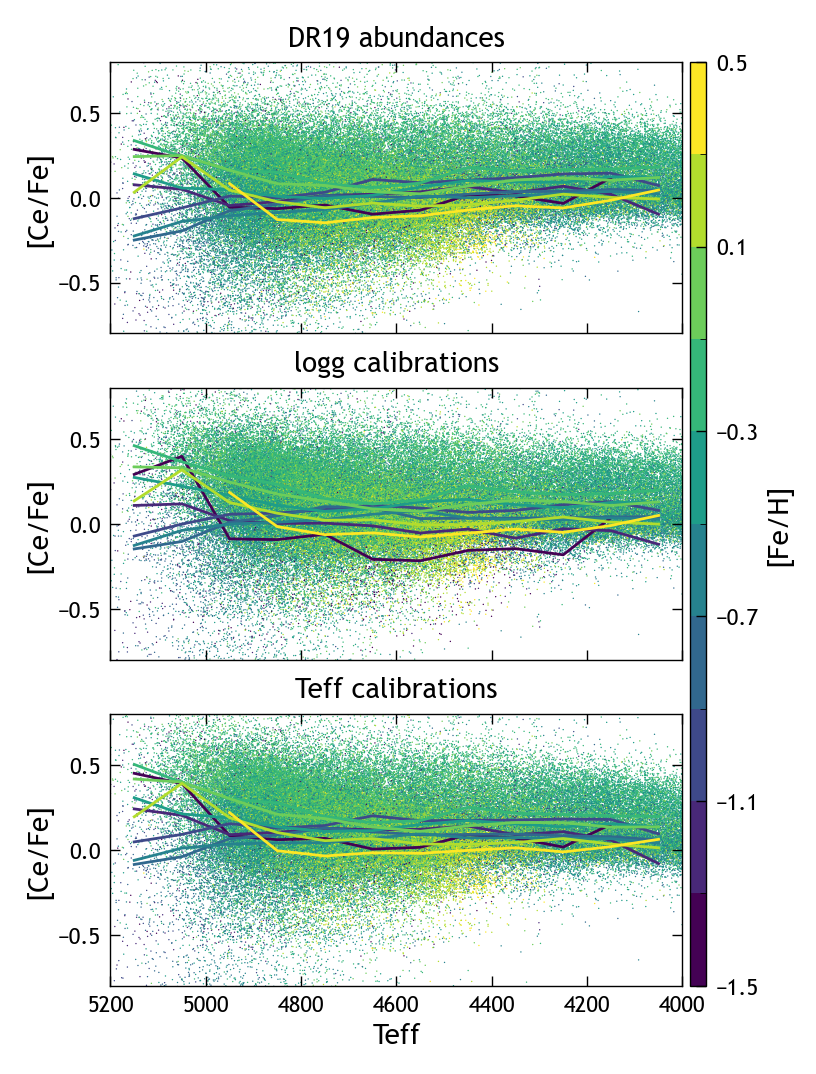

In [51]:
fig, axs = plt.subplots(3, figsize=(4, 6), sharex=True, sharey=True)
cax = insert_colorbar_axes(fig)
kwargs = dict(rasterized=True, edgecolors='none', marker='.', s=1)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(feh_bins, cmap.N)
pc = axs[0].scatter(mwm_rgb['teff'], mwm_rgb['ce_fe'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
axs[1].scatter(mwm_rgb['teff'], mwm_rgb['ce_fe_corr'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
axs[2].scatter(mwm_rgb['teff'], mwm_rgb['ce_fe_corr2'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
for i in range(feh_bins.shape[0]-1):
    feh_bin_sample = mwm_rgb[(mwm_rgb['fe_h'] >= feh_bins[i]) & (mwm_rgb['fe_h'] < feh_bins[i+1])]
    teff_medians = binned_quantiles(feh_bin_sample, 'ce_fe', 'teff', q=0.5, bin_edges=teff_bins)
    axs[0].plot(*teff_medians, color=cmap(norm(feh_bin_centers[i])))
    teff_medians = binned_quantiles(feh_bin_sample, 'ce_fe_corr', 'teff', q=0.5, bin_edges=teff_bins)
    axs[1].plot(*teff_medians, color=cmap(norm(feh_bin_centers[i])))
    teff_medians = binned_quantiles(feh_bin_sample, 'ce_fe_corr2', 'teff', q=0.5, bin_edges=teff_bins)
    axs[2].plot(*teff_medians, color=cmap(norm(feh_bin_centers[i])))
fig.colorbar(pc, cax=cax, label='[Fe/H]')
axs[0].set_xlim((5200, 4000))
axs[0].set_ylim((-0.8, 0.8))
axs[-1].set_xlabel('Teff')
axs[0].set_ylabel('[Ce/Fe]')
axs[1].set_ylabel('[Ce/Fe]')
axs[2].set_ylabel('[Ce/Fe]')
axs[0].set_title('DR19 abundances')
axs[1].set_title('logg calibrations')
axs[2].set_title('Teff calibrations')
plt.show()

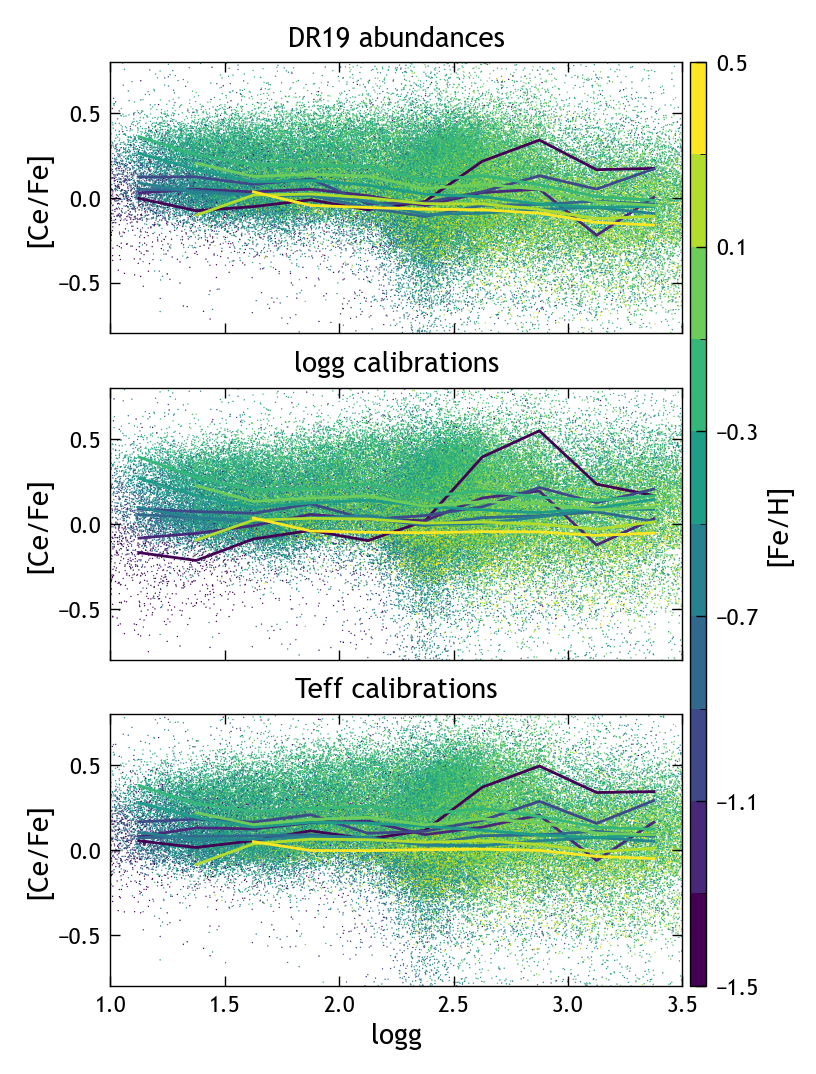

In [49]:
fig, axs = plt.subplots(3, figsize=(4, 6), sharex=True, sharey=True)
cax = insert_colorbar_axes(fig)
kwargs = dict(rasterized=True, edgecolors='none', marker='.', s=1)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(feh_bins, cmap.N)
pc = axs[0].scatter(mwm_rgb['logg'], mwm_rgb['ce_fe'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
axs[1].scatter(mwm_rgb['logg'], mwm_rgb['ce_fe_corr'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
axs[2].scatter(mwm_rgb['logg'], mwm_rgb['ce_fe_corr2'], c=mwm_rgb['fe_h'], cmap=cmap, norm=norm, **kwargs)
for i in range(feh_bins.shape[0]-1):
    feh_bin_sample = mwm_rgb[(mwm_rgb['fe_h'] >= feh_bins[i]) & (mwm_rgb['fe_h'] < feh_bins[i+1])]
    logg_medians = binned_quantiles(feh_bin_sample, 'ce_fe', 'logg', q=0.5, bin_edges=logg_bins)
    axs[0].plot(*logg_medians, color=cmap(norm(feh_bin_centers[i])))
    logg_medians = binned_quantiles(feh_bin_sample, 'ce_fe_corr', 'logg', q=0.5, bin_edges=logg_bins)
    axs[1].plot(*logg_medians, color=cmap(norm(feh_bin_centers[i])))
    logg_medians = binned_quantiles(feh_bin_sample, 'ce_fe_corr2', 'logg', q=0.5, bin_edges=logg_bins)
    axs[2].plot(*logg_medians, color=cmap(norm(feh_bin_centers[i])))
fig.colorbar(pc, cax=cax, label='[Fe/H]')
axs[0].set_xlim((1, 3.5))
axs[0].set_ylim((-0.8, 0.8))
axs[-1].set_xlabel('logg')
axs[0].set_ylabel('[Ce/Fe]')
axs[1].set_ylabel('[Ce/Fe]')
axs[2].set_ylabel('[Ce/Fe]')
axs[0].set_title('DR19 abundances')
axs[1].set_title('logg calibrations')
axs[2].set_title('Teff calibrations')
plt.show()

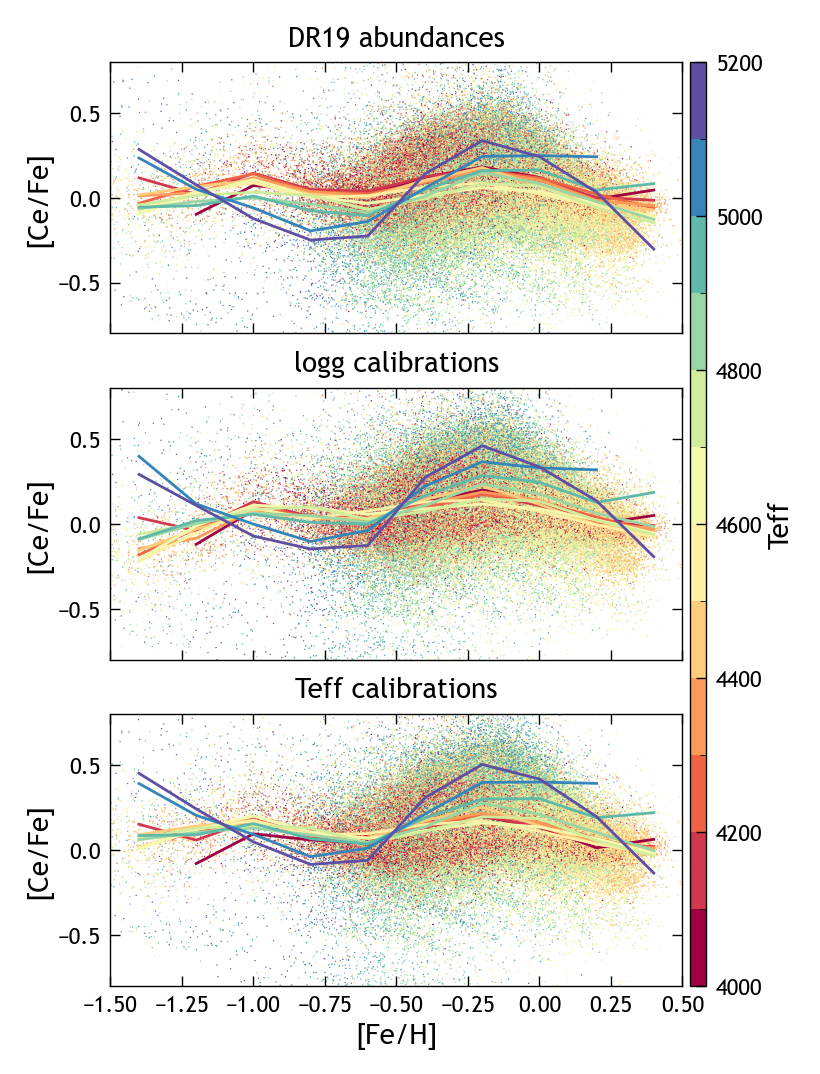

In [53]:
fig, axs = plt.subplots(3, figsize=(4, 6), sharex=True, sharey=True)
cax = insert_colorbar_axes(fig)
kwargs = dict(rasterized=True, edgecolors='none', marker='.', s=1)
cmap = plt.get_cmap('Spectral')
norm = BoundaryNorm(teff_bins, cmap.N)
pc = axs[0].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe'], c=mwm_rgb['teff'], cmap=cmap, norm=norm, **kwargs)
axs[1].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe_corr'], c=mwm_rgb['teff'], cmap=cmap, norm=norm, **kwargs)
axs[2].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe_corr2'], c=mwm_rgb['teff'], cmap=cmap, norm=norm, **kwargs)
for i in range(teff_bins.shape[0]-1):
    teff_bin_sample = mwm_rgb[(mwm_rgb['teff'] >= teff_bins[i]) & (mwm_rgb['teff'] < teff_bins[i+1])]
    feh_medians = binned_quantiles(teff_bin_sample, 'ce_fe', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[0].plot(*feh_medians, color=cmap(norm(teff_bin_centers[i])))
    feh_medians = binned_quantiles(teff_bin_sample, 'ce_fe_corr', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[1].plot(*feh_medians, color=cmap(norm(teff_bin_centers[i])))
    feh_medians = binned_quantiles(teff_bin_sample, 'ce_fe_corr2', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[2].plot(*feh_medians, color=cmap(norm(teff_bin_centers[i])))
fig.colorbar(pc, cax=cax, label='Teff')
axs[0].set_xlim((-1.5, 0.5))
axs[0].set_ylim((-0.8, 0.8))
axs[-1].set_xlabel('[Fe/H]')
axs[0].set_ylabel('[Ce/Fe]')
axs[1].set_ylabel('[Ce/Fe]')
axs[2].set_ylabel('[Ce/Fe]')
axs[0].set_title('DR19 abundances')
axs[1].set_title('logg calibrations')
axs[2].set_title('Teff calibrations')
plt.show()

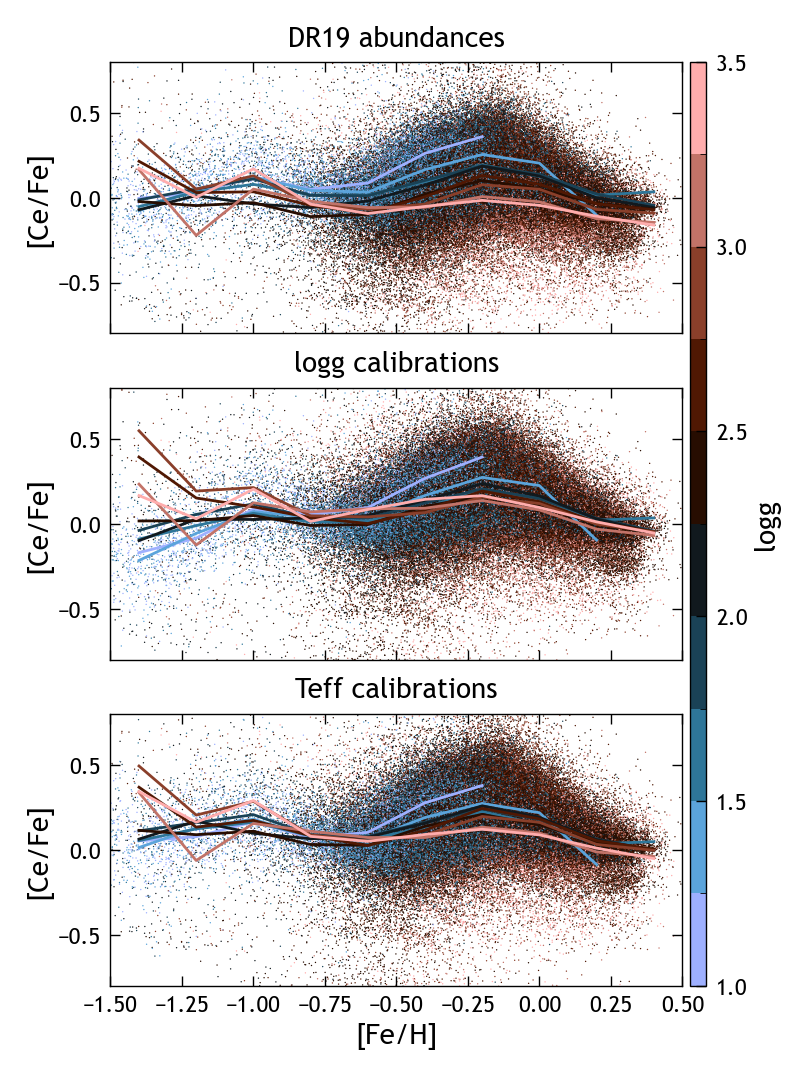

In [56]:
fig, axs = plt.subplots(3, figsize=(4, 6), sharex=True, sharey=True)
cax = insert_colorbar_axes(fig)
kwargs = dict(rasterized=True, edgecolors='none', marker='.', s=1)
cmap = plt.get_cmap('berlin')
norm = BoundaryNorm(logg_bins, cmap.N)
pc = axs[0].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe'], c=mwm_rgb['logg'], cmap=cmap, norm=norm, **kwargs)
axs[1].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe_corr'], c=mwm_rgb['logg'], cmap=cmap, norm=norm, **kwargs)
axs[2].scatter(mwm_rgb['fe_h'], mwm_rgb['ce_fe_corr2'], c=mwm_rgb['logg'], cmap=cmap, norm=norm, **kwargs)
for i in range(logg_bins.shape[0]-1):
    logg_bin_sample = mwm_rgb[(mwm_rgb['logg'] >= logg_bins[i]) & (mwm_rgb['logg'] < logg_bins[i+1])]
    feh_medians = binned_quantiles(logg_bin_sample, 'ce_fe', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[0].plot(*feh_medians, color=cmap(norm(logg_bin_centers[i])))
    feh_medians = binned_quantiles(logg_bin_sample, 'ce_fe_corr', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[1].plot(*feh_medians, color=cmap(norm(logg_bin_centers[i])))
    feh_medians = binned_quantiles(logg_bin_sample, 'ce_fe_corr2', 'fe_h', q=0.5, bin_edges=feh_bins)
    axs[2].plot(*feh_medians, color=cmap(norm(logg_bin_centers[i])))
fig.colorbar(pc, cax=cax, label='logg')
axs[0].set_xlim((-1.5, 0.5))
axs[0].set_ylim((-0.8, 0.8))
axs[-1].set_xlabel('[Fe/H]')
axs[0].set_ylabel('[Ce/Fe]')
axs[1].set_ylabel('[Ce/Fe]')
axs[2].set_ylabel('[Ce/Fe]')
axs[0].set_title('DR19 abundances')
axs[1].set_title('logg calibrations')
axs[2].set_title('Teff calibrations')
plt.show()